<a href="https://colab.research.google.com/gist/ico88/c365f4608784e5b5c1a2516efe1b7bf6/prophet-mic-v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cella 1: Installazione librerie e caricamento dati
# Installazione delle librerie necessarie
!pip install prophet
!pip install scikit-learn
!pip install --upgrade pandas matplotlib
!pip install tqdm
!pip install openpyxl

# Importazioni
import pandas as pd
import numpy as np
from prophet import Prophet
import joblib
import ipywidgets as widgets
from ipywidgets import Dropdown, Button, Output, VBox, interactive
from IPython.display import display, clear_output
import datetime
import matplotlib.pyplot as plt
from prophet.diagnostics import cross_validation, performance_metrics
import joblib
from tqdm.notebook import tqdm
from joblib import Parallel, delayed, dump, load
from sklearn.metrics import mean_squared_error, mean_absolute_error # Aggiunto MAE

# Caricamento del dataset e pulizia iniziale
import glob

# Crea una lista di tutti i file .xlsx nella cartella /content/ che iniziano con 'RETEMIC'
file_paths = glob.glob('/content/RETEMIC_19_24.xlsx')

# Unisce tutti i file in un unico DataFrame
df_reale = pd.DataFrame()
for file_path in file_paths:
    df_temp = pd.read_excel(file_path)
    df_reale = pd.concat([df_reale, df_temp], ignore_index=True)

# Continua con il resto della pulizia
df_reale = df_reale.rename(columns={'MICROORGANISMO': 'patogeno'})

# Usa format='mixed' ed errors='coerce' per gestire formati diversi e valori non validi
df_reale['DATA_PRELIEVO'] = pd.to_datetime(df_reale['DATA_PRELIEVO'], format='mixed', dayfirst=True, errors='coerce')

In [ ]:
# Cella 2 Aggregazione dei dati
# Crea un DataFrame vuoto per i dati aggregati
df_aggregato = pd.DataFrame()

# Filtra i dati precedenti al 01/01/2019
df_reale = df_reale[df_reale['DATA_PRELIEVO'] >= '2019-01-01'].copy()

# --- NUOVO PASSAGGIO DI PULIZIA ---
# Rimuove gli spazi extra e uniforma i valori del patogeno
if 'patogeno' in df_reale.columns:
  df_reale['patogeno'] = df_reale['patogeno'].str.strip()

# Lista degli antibiotici da processare
antibiotici_list = df_reale.columns[df_reale.columns.str.endswith('_QUALITATIVO')].str.replace('_QUALITATIVO', '').tolist()

# Esclusione dei campioni senza risultati di antibiotico
colonne_risultati_antibiotici = [f'{antibiotico}_QUALITATIVO' for antibiotico in antibiotici_list]
df_reale = df_reale.dropna(subset=colonne_risultati_antibiotici, how='all')

for antibiotico in antibiotici_list:
    col_qual = f'{antibiotico}_QUALITATIVO'

    if col_qual in df_reale.columns:
        df_temp = df_reale[['DATA_PRELIEVO', 'patogeno', 'LABORATORIO', col_qual]].copy()
        df_temp = df_temp.rename(columns={col_qual: 'risultato'})
        df_temp['antibiotico'] = antibiotico
        df_temp = df_temp.dropna(subset=['risultato'])

        if not df_temp.empty:
            df_conteggi = df_temp.groupby([
                pd.Grouper(key='DATA_PRELIEVO', freq='ME'),
                'patogeno',
                'LABORATORIO',
                'antibiotico',
                'risultato'
            ]).size().unstack(fill_value=0)

            df_percentuali = df_conteggi.div(df_conteggi.sum(axis=1), axis=0) * 100

            df_final = pd.merge(df_conteggi.reset_index(), df_percentuali.reset_index(), on=['DATA_PRELIEVO', 'patogeno', 'LABORATORIO', 'antibiotico'])

            df_aggregato = pd.concat([df_aggregato, df_final], ignore_index=True)

df_aggregato = df_aggregato.rename(columns={
    'R_x': 'Conteggio_R', 'I_x': 'Conteggio_I', 'S_x': 'Conteggio_S',
    'R_y': 'resistenti', 'I_y': 'intermedi', 'S_y': 'sensibili'
})

if all(col in df_aggregato.columns for col in ['Conteggio_R', 'Conteggio_I', 'Conteggio_S']):
    df_aggregato['Totale_Campioni'] = df_aggregato['Conteggio_R'] + df_aggregato['Conteggio_I'] + df_aggregato['Conteggio_S']

df_aggregato['DATA_PRELIEVO'] = pd.to_datetime(df_aggregato['DATA_PRELIEVO'])
df_aggregato = df_aggregato.rename(columns={'DATA_PRELIEVO': 'data'})

# Crea la colonna 'combinazione_unica'
df_aggregato['combinazione_unica'] = df_aggregato['patogeno'] + '_' + df_aggregato['LABORATORIO'] + '_' + df_aggregato['antibiotico']

print("--- DataFrame Aggregato Completato ---")
print(df_aggregato.head())

--- DataFrame Aggregato Completato ---
risultato       data patogeno LABORATORIO antibiotico   _x  Conteggio_I  IE_x  \
0         2019-01-31   ACISPP       IT161         AMK  0.0          1.0   0.0   
1         2019-01-31   ACISPP       IT164         AMK  0.0          0.0   0.0   
2         2019-01-31   ACISPP       IT170         AMK  0.0          0.0   0.0   
3         2019-01-31   ACISPP       IT171         AMK  0.0          0.0   0.0   
4         2019-01-31   ACISPP       IT173         AMK  0.0          0.0   0.0   

risultato  ND_x  Conteggio_R  Conteggio_S  ...  <0.5_y  >8_y  <=0.12_x  >=8_x  \
0           0.0            0          0.0  ...     NaN   NaN       NaN    NaN   
1           0.0            2          0.0  ...     NaN   NaN       NaN    NaN   
2           0.0            6          0.0  ...     NaN   NaN       NaN    NaN   
3           0.0            2          2.0  ...     NaN   NaN       NaN    NaN   
4           0.0            1          1.0  ...     NaN   NaN       Na

In [ ]:
if 'df_reale' not in globals():
    print("⚠ La variabile 'df_reale' non è stata trovata. Assicurati di aver eseguito la Cella 1 per caricare i dati.")
else:
    # --- MAPPING DELLE CLASSI DI ANTIBIOTICI ---
    # Questo dizionario mappa i nomi delle classi (usati nella tua lista) ai codici di 3 lettere (usati nel tuo dataset)
    mapping_classi = {
        'GLICOPEPTIDI': ['VAN', 'TPL'],
        'LIPOPEPTIDI': ['DAP'],
        'MACROLIDI': ['ERY', 'AZM'],
        'NITROFURANI': ['NIT'], # Assumendo un codice Nitrofurano se presente
        'OSSAZOLIDINONI': ['LZD'],
        'CEFALOSPORINE II': ['FOX'],
        'CEFALOSPORINE V': ['CPT'],
        'PENICILLINE': ['AMP'],
        'CEFALOSPORINE III + INIBITORE': ['CAZ', 'CZA'], # Esempio: Ceftazidime/Avibactam
        'CEFALOSPORINE IV': ['FEP'],
        'CEFALOSPORINE V + INIBITORE': ['CZT'],
        'POLIMIXINE': ['COL'],
        'LICOPEPTIDI': ['DAP'], # Duplicato per chiarezza
        'RIFAMPICINE': ['RIF'], # Assumendo un codice Rifampicina
        'TETRACILLINE': ['TGC'], # Assumendo un codice Tetraciclina
        'AMMINOGLICOSIDI': ['AMK', 'GEN'],
        'FOSFOMICINA': ['FOS'],
        'PENNICILLINE + INIBIITORE': ['AMC']
    }

    # Funzione per ottenere tutti i codici esatti da una lista di classi
    def get_antibiotic_codes(class_list):
        codes = set()
        for class_name in class_list:
            codes.update(mapping_classi.get(class_name, []))
        return [c + '_QUALITATIVO' for c in codes if c + '_QUALITATIVO' in df_reale.columns]


    # --- DEFINIZIONE DELLE COMBINAZIONI DA ESCLUDERE ---
    # La tua lista, tradotta in codici di antibiotici
    esclusioni_per_specie = {
        'KLEPNE': get_antibiotic_codes(['GLICOPEPTIDI', 'LIPOPEPTIDI', 'MACROLIDI', 'NITROFURANI', 'OSSAZOLIDINONI']),
        'ACISPP': get_antibiotic_codes(['CEFALOSPORINE II', 'CEFALOSPORINE V', 'GLICOPEPTIDI', 'LIPOPEPTIDI', 'MACROLIDI', 'OSSAZOLIDINONI', 'PENICILLINE']),
        'ENTFCM': get_antibiotic_codes(['CEFALOSPORINE II', 'CEFALOSPORINE III + INIBITORE', 'CEFALOSPORINE IV', 'CEFALOSPORINE V', 'CEFALOSPORINE V + INIBITORE', 'POLIMIXINE']),
        'ESCCOL': get_antibiotic_codes(['GLICOPEPTIDI', 'LIPOPEPTIDI', 'MACROLIDI', 'NITROFURANI', 'OSSAZOLIDINONI']),
        'ENTFAE': get_antibiotic_codes(['CEFALOSPORINE II', 'CEFALOSPORINE III + INIBITORE', 'CEFALOSPORINE IV', 'CEFALOSPORINE V + INIBITORE', 'POLIMIXINE']),
        'PSEAER': get_antibiotic_codes(['CEFALOSPORINE II', 'CEFALOSPORINE V', 'LICOPEPTIDI', 'LIPOPEPTIDI', 'MACROLIDI', 'OSSAZOLIDINONI', 'RIFAMPICINE', 'TETRACILLINE']),
        'STAAUR': get_antibiotic_codes(['CEFALOSPORINE V + INIBITORE', 'NITROFURANI', 'POLIMIXINE']),
        'STRPNE': get_antibiotic_codes(['AMMINOGLICOSIDI', 'CEFALOSPORINE II', 'CEFALOSPORINE III + INIBITORE', 'CEFALOSPORINE IV', 'CEFALOSPORINE V', 'CEFALOSPORINE V + INIBITORE', 'FOSFOMICINA', 'OSSAZOLIDINONI', 'PENNICILLINE + INIBIITORE', 'RIFAMPICINE'])
    }

    # 1. Pulizia e Filtro Iniziale dei Dati

    # Filtra i dati precedenti al 01/01/2019
    df_reale = df_reale[df_reale['DATA_PRELIEVO'] >= '2019-01-01'].copy()

    # Uniforma i valori del patogeno eliminando gli spazi extra
    if 'patogeno' in df_reale.columns:
        df_reale['patogeno'] = df_reale['patogeno'].str.strip()

    # Esclusione dei campioni senza risultati di antibiotico
    colonne_antibiotici = [col for col in df_reale.columns if '_QUALITATIVO' in col]
    df_reale = df_reale.dropna(subset=colonne_antibiotici, how='all')

    # --- 2a. ESCLUSIONE DELLE COMBINAZIONI PER RESISTENZA INTRINSECA ---
    # Rimuove i risultati per le combinazioni specificate (imposta a NaN)
    for specie, cols_to_exclude in esclusioni_per_specie.items():
        condizione = df_reale['patogeno'] == specie
        for col_qual in cols_to_exclude:
            col_quant = col_qual.replace('_QUALITATIVO', '_QUANTITATIVO')
            # Imposta il valore qualitativo e quantitativo a NaN
            df_reale.loc[condizione, col_qual] = np.nan
            if col_quant in df_reale.columns:
                 df_reale.loc[condizione, col_quant] = np.nan

    print("✅ Esclusione dei test per resistenza intrinseca completata (impostati a NaN).")

    # 2. Gestione e Unione dei Campioni Duplicati (Risoluzione R > I > S)
    colonne_chiave = ['DATA_PRELIEVO', 'CODICE_CAMPIONE', 'LABORATORIO', 'patogeno']
    df_duplicati = df_reale[df_reale.duplicated(subset=colonne_chiave, keep=False)].copy()
    df_unici = df_reale.drop_duplicates(subset=colonne_chiave, keep=False).copy()

    # Il resto della logica di gestione dei duplicati rimane invariata
    if df_duplicati.empty:
        df_pulito = df_reale.copy()
        print("✅ Non sono stati trovati campioni duplicati. Nessuna azione di unione necessaria.")
    else:
        print(f"❌ Trovati {len(df_duplicati.drop_duplicates(subset=colonne_chiave))} campioni duplicati. Risoluzione automatica dei conflitti R/I/S in corso...")

        # Definisce la regola di priorità R > I > S
        gerarchia_risultati = {'R': 3, 'I': 2, 'S': 1}

        gruppi_consolidati = []
        gruppi_conflitto_non_SIR = []

        for chiave, gruppo in df_duplicati.groupby(colonne_chiave):

            merged_row = gruppo.iloc[0].copy()
            is_true_conflict = False

            for col in colonne_antibiotici:
                # Assicurati che i valori originali siano usati per trovare il MIC corrispondente
                valori_qualitativi = gruppo[col].dropna()

                if valori_qualitativi.empty:
                    merged_row[col] = np.nan
                    continue

                risultato_finale = np.nan
                priorita_massima = -1

                for val in valori_qualitativi.unique():
                    priorita = gerarchia_risultati.get(val, 0)

                    if priorita == 0 and priorita_massima > 0:
                        is_true_conflict = True
                        break

                    if priorita > priorita_massima:
                        priorita_massima = priorita
                        risultato_finale = val

                if is_true_conflict:
                    break

                merged_row[col] = risultato_finale

                # Gestisce la colonna QUANTITATIVA (MIC) associata
                col_quant = col.replace('_QUALITATIVO', '_QUANTITATIVO')
                if col_quant in gruppo.columns:
                    matching_rows = gruppo[gruppo[col] == risultato_finale]
                    if not matching_rows.empty:
                        mic_val = matching_rows[col_quant].dropna()
                        merged_row[col_quant] = mic_val.iloc[0] if not mic_val.empty else np.nan
                    else:
                         merged_row[col_quant] = np.nan

            if is_true_conflict:
                gruppi_conflitto_non_SIR.append(gruppo)
            else:
                gruppi_consolidati.append(merged_row)

        df_consolidato = pd.DataFrame(gruppi_consolidati)
        df_pulito = pd.concat([df_unici, df_consolidato], ignore_index=True)

        print(f"\n✅ {len(df_consolidato)} campioni duplicati consolidati con successo (priorità R > I > S).")

        # Esporta solo i veri conflitti (non R/I/S) per revisione
        if gruppi_conflitto_non_SIR:
            df_conflitti_veri = pd.concat(gruppi_conflitto_non_SIR, ignore_index=True)
            df_conflitti_veri.to_excel('campioni_conflitto_da_revisionare_VERI.xlsx', index=False)
            print(f"❗ Rimangono {len(df_conflitti_veri.drop_duplicates(subset=colonne_chiave))} campioni con **veri conflitti di qualità dati** (non R/I/S). Dettagli salvati in 'campioni_conflitto_da_revisionare_VERI.xlsx'.")

    print(f"\nDataFrame pronto per l'aggregazione con {len(df_pulito)} righe.")

    # --- Riepilogo Totale Test per Anno
    print("\n--- Conteggio Totale Test per Anno ---")
    df_pulito['DATA_PRELIEVO'] = pd.to_datetime(df_pulito['DATA_PRELIEVO'])

    conteggio_test_per_anno = pd.DataFrame()
    df_pulito['ANNO_PRELIEVO'] = df_pulito['DATA_PRELIEVO'].dt.year

    for anno in sorted(df_pulito['ANNO_PRELIEVO'].unique()):
        df_anno = df_pulito[df_pulito['ANNO_PRELIEVO'] == anno]
        conteggio_test = sum(df_anno[col].notna().sum() for col in colonne_antibiotici)
        conteggio_test_per_anno = pd.concat([
            conteggio_test_per_anno,
            pd.DataFrame([{'ANNO': anno, 'Numero Test': conteggio_test}])
        ], ignore_index=True)

    print(conteggio_test_per_anno.to_string(index=False))

    # 3. Aggregazione dei dati da "df_pulito"
    df_aggregato = pd.DataFrame()
    antibiotici_list = [col.replace('_QUALITATIVO', '') for col in colonne_antibiotici]

    for antibiotico in antibiotici_list:
        col_qual = f'{antibiotico}_QUALITATIVO'
        df_temp = df_pulito[['DATA_PRELIEVO', 'patogeno', 'LABORATORIO', col_qual]].copy()
        df_temp = df_temp.rename(columns={col_qual: 'risultato'})
        df_temp['antibiotico'] = antibiotico
        df_temp = df_temp.dropna(subset=['risultato'])

        if not df_temp.empty:
            df_conteggi = df_temp.groupby([
                pd.Grouper(key='DATA_PRELIEVO', freq='ME'),
                'patogeno',
                'LABORATORIO',
                'antibiotico',
                'risultato'
            ]).size().unstack(fill_value=0)

            df_percentuali = df_conteggi.div(df_conteggi.sum(axis=1), axis=0) * 100

            df_final = pd.merge(df_conteggi.reset_index(), df_percentuali.reset_index(), on=['DATA_PRELIEVO', 'patogeno', 'LABORATORIO', 'antibiotico'])

            df_aggregato = pd.concat([df_aggregato, df_final], ignore_index=True)

    df_aggregato = df_aggregato.rename(columns={
        'R_x': 'Conteggio_R', 'I_x': 'Conteggio_I', 'S_x': 'Conteggio_S',
        'R_y': 'resistenti', 'I_y': 'intermedi', 'S_y': 'sensibili'
    })

    if all(col in df_aggregato.columns for col in ['Conteggio_R', 'Conteggio_I', 'Conteggio_S']):
        df_aggregato['Totale_Campioni'] = df_aggregato['Conteggio_R'] + df_aggregato['Conteggio_I'] + df_aggregato['Conteggio_S']

    df_aggregato['DATA_PRELIEVO'] = pd.to_datetime(df_aggregato['DATA_PRELIEVO'])
    df_aggregato = df_aggregato.rename(columns={'DATA_PRELIEVO': 'data'})

    # Crea la colonna 'combinazione_unica'
    df_aggregato['combinazione_unica'] = df_aggregato['patogeno'] + '_' + df_aggregato['LABORATORIO'] + '_' + df_aggregato['antibiotico']

    print("\n--- DataFrame Aggregato Completato ---")
    print(df_aggregato.head())

✅ Esclusione dei test per resistenza intrinseca completata (impostati a NaN).
❌ Trovati 1774 campioni duplicati. Risoluzione automatica dei conflitti R/I/S in corso...

✅ 1747 campioni duplicati consolidati con successo (priorità R > I > S).
❗ Rimangono 1 campioni con **veri conflitti di qualità dati** (non R/I/S). Dettagli salvati in 'campioni_conflitto_da_revisionare_VERI.xlsx'.

DataFrame pronto per l'aggregazione con 84619 righe.

--- Conteggio Totale Test per Anno ---
 ANNO  Numero Test
 2019        61425
 2020        47272
 2021        52633
 2022        65054
 2023       311938
 2024       407343

--- DataFrame Aggregato Completato ---
risultato       data patogeno LABORATORIO antibiotico   _x  Conteggio_I  IE_x  \
0         2019-01-31   ACISPP       IT161         AMK  0.0          1.0   0.0   
1         2019-01-31   ACISPP       IT164         AMK  0.0          0.0   0.0   
2         2019-01-31   ACISPP       IT170         AMK  0.0          0.0   0.0   
3         2019-01-31   AC

In [ ]:
#Cella 3 verifica tramite UI dei dati presenti
print("### Cella di verifica dei dati")
# Estrarre le liste uniche per i menu a tendina
patogeni_unici = sorted(df_aggregato['patogeno'].unique())
anni_unici = sorted(df_aggregato['data'].dt.year.unique())  # Corretto il nome della colonna
antibiotici_unici = sorted(df_aggregato['antibiotico'].unique())

# Creazione dei widget interattivi
patogeno_select = widgets.Dropdown(
    options=patogeni_unici,
    description='Patogeno:',
    disabled=False,
)

anno_select = widgets.Dropdown(
    options=anni_unici,
    description='Anno:',
    disabled=False,
)

antibiotico_select = widgets.Dropdown(
    options=antibiotici_unici,
    description='Antibiotico:',
    disabled=False,
)

# Funzione che verrà chiamata ogni volta che l'utente fa una selezione
def visualizza_risultati(patogeno, anno, antibiotico):
    clear_output(wait=True)
    print("\n--- Risultati Analisi ---")

    # Filtra il DataFrame in base alle selezioni dell'utente
    df_filtro = df_aggregato[
        (df_aggregato['patogeno'] == patogeno) &
        (df_aggregato['data'].dt.year == anno) &  # Corretto il nome della colonna
        (df_aggregato['antibiotico'] == antibiotico)
    ]

    if not df_filtro.empty:
        # Calcola le medie e il numero totale di test
        conteggio_r = df_filtro.get('Conteggio_R', pd.Series([0])).sum()
        conteggio_i = df_filtro.get('Conteggio_I', pd.Series([0])).sum()
        conteggio_s = df_filtro.get('Conteggio_S', pd.Series([0])).sum()

        numero_test = conteggio_r + conteggio_i + conteggio_s

        # Ricalcola le percentuali basandoti sui conteggi effettivi per maggiore precisione
        resistenza_percentuale = (conteggio_r / numero_test) * 100 if numero_test > 0 else 0
        sensibilita_percentuale = (conteggio_s / numero_test) * 100 if numero_test > 0 else 0
        intermedi_percentuale = (conteggio_i / numero_test) * 100 if numero_test > 0 else 0

        print(f"✅ Dati trovati per la selezione.")
        print(f"Numero totale di test effettuati per la combinazione: {int(numero_test)}")
        print(f"Resistenza media per {patogeno} e {antibiotico} nel {anno}: {resistenza_percentuale:.2f}%")
        print(f"Sensibilità media per {patogeno} e {antibiotico} nel {anno}: {sensibilita_percentuale:.2f}%")
        print(f"Intermedi medi per {patogeno} e {antibiotico} nel {anno}: {intermedi_percentuale:.2f}%")

        # Mostra una tabella con i dati mensili
        display(df_filtro[['data', 'resistenti', 'intermedi', 'sensibili']].reset_index(drop=True))  # Corretto il nome della colonna
    else:
        print("⚠ Nessun dato trovato per questa combinazione. Prova una selezione diversa.")

# Collega i widget alla funzione di visualizzazione
widgets.interactive(visualizza_risultati, patogeno=patogeno_select, anno=anno_select, antibiotico=antibiotico_select)

### Cella di verifica dei dati


interactive(children=(Dropdown(description='Patogeno:', options=('ACISPP', 'ENTFAE', 'ENTFCM', 'ESCCOL', 'KLEP…

In [ ]:
# Cella 4: Addestramento e Valutazione (Versione Finale con Logica MASE/MAPE/Varianza)

# Importazioni (Assumiamo siano già state fatte in Cella 1)
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
from prophet import Prophet
from joblib import Parallel, delayed, dump, load
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

# Funzione Helper per calcolare MASE
def calculate_mase(y_true, y_pred, y_train):
    """Calcola il Mean Absolute Scaled Error (MASE)."""
    if len(y_train) < 2:
        return np.nan # Non si può calcolare la baseline

    # Baseline: Errore assoluto del modello ingenuo (prevede il valore precedente)
    mae_baseline = np.mean(np.abs(y_train[1:] - y_train[:-1]))
    if mae_baseline == 0:
        return np.nan # Evita divisione per zero se la serie di training è costante

    # Errore assoluto del nostro modello sulle previsioni di test
    mae_model = np.mean(np.abs(y_true - y_pred))

    return mae_model / mae_baseline


# --- SOGLIA DI VARIANZA E DI FILTRO DATI ---
# Questa soglia ignora le serie troppo piatte o troppo volatili (Varianza > 750)
VARIANCE_THRESHOLD = 750.0

# DEFINISCI L'ULTIMA DATA DI CUI TI FIDI PER L'ADDESTRAMENTO
# Basato sull'analisi della copertura, usiamo la fine del 2024.
MAX_TRAINING_DATE = pd.to_datetime('2024-12-31')
# --- SOGLIA DI VARIANZA E DI FILTRO DATI ---


# Definisci i dizionari globali per salvare i risultati
previsioni_resistenti = {}
previsioni_intermedi = {}
previsioni_sensibili = {}

# Dizionari per salvare le metriche estese
metrics_data = {
    'resistenti': {'rmse': {}, 'mape': {}, 'mase': {}},
    'intermedi': {'rmse': {}, 'mape': {}, 'mase': {}},
    'sensibili': {'rmse': {}, 'mape': {}, 'mase': {}}
}


def process_combination_and_cross_validate(combinazione, df_combinazione_completo, targets):
    """
    Funzione per addestrare, prevedere e validare un singolo modello.
    Calcola RMSE, MAPE e MASE.
    """
    local_previsioni = {}
    local_metrics = {'rmse': {}, 'mape': {}, 'mase': {}}

    try:
        # Varianza Check
        max_variance = df_combinazione_completo[['resistenti', 'intermedi', 'sensibili']].var().max()
        if max_variance > VARIANCE_THRESHOLD:
            return combinazione, {}, {}
    except:
        return combinazione, {}, {}

    # Filtra il set completo fino alla data massima affidabile (fine 2024)
    df_combinazione_completo = df_combinazione_completo[df_combinazione_completo['data'] <= MAX_TRAINING_DATE].copy()

    # Date di CV definite per testare l'accuratezza su periodi storici stabili
    cv_dates = pd.to_datetime(['2023-01-31', '2023-06-30', '2023-12-31', '2024-06-30'])
    # Rimuovi le CV dates che cadono dopo MAX_TRAINING_DATE
    cv_dates = cv_dates[cv_dates < MAX_TRAINING_DATE]

    for target in targets:
        df_prophet_completo = df_combinazione_completo[['data', target]].rename(columns={'data': 'ds', target: 'y'})
        df_prophet_completo['cap'] = 100.0
        df_prophet_completo['floor'] = 0.0

        y_data = df_prophet_completo['y'].dropna()
        if y_data.empty or len(y_data) < 12:
            continue

        # Addestramento finale per la previsione UI (usa tutti i dati fino a MAX_TRAINING_DATE)
        df_train_final = df_prophet_completo.copy()
        model_final = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False)
        model_final.fit(df_train_final)

        # Previsione per 2 anni (12*2) oltre l'ultima data di training (MAX_TRAINING_DATE)
        futuro = model_final.make_future_dataframe(periods=12*2, freq='ME')
        futuro['cap'] = 100.0
        futuro['floor'] = 0.0
        forecast_final = model_final.predict(futuro)

        # Clamping della previsione finale tra 0 e 100
        forecast_final['yhat'] = np.clip(forecast_final['yhat'], 0, 100)
        local_previsioni[target] = forecast_final[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]


        # Cross-validation per calcolare le metriche
        rmse_values, mape_values, mase_values = [], [], []

        if len(cv_dates) == 0:
            continue

        for end_date in cv_dates:
            df_train_cv = df_prophet_completo[df_prophet_completo['ds'] <= end_date].copy()
            df_test_cv = df_prophet_completo[(df_prophet_completo['ds'] > end_date) & (df_prophet_completo['ds'] <= end_date + pd.DateOffset(months=6))].copy()

            if len(df_train_cv) < 2 or df_test_cv.empty:
                continue

            model_cv = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False)
            model_cv.fit(df_train_cv)

            forecast_cv = model_cv.predict(df_test_cv)
            y_pred = forecast_cv['yhat'].values
            y_true = df_test_cv['y'].values

            y_train_mase = df_train_cv['y'].values

            if len(y_true) > 0 and len(y_pred) > 0:
                y_pred_clipped = np.clip(y_pred, 0, 100)

                # Calcolo RMSE
                rmse = np.sqrt(mean_squared_error(y_true, y_pred_clipped))
                rmse_values.append(rmse)

                # Calcolo MAPE (piccola stabilizzazione per lo zero)
                y_true_stable = np.where(y_true == 0, 0.0001, y_true)
                mape = np.mean(np.abs((y_true - y_pred_clipped) / y_true_stable)) * 100
                mape_values.append(mape)

                # Calcolo MASE
                mase = calculate_mase(y_true, y_pred_clipped, y_train_mase)
                if not np.isnan(mase):
                    mase_values.append(mase)

        if rmse_values:
            local_metrics['rmse'][target] = np.mean(rmse_values)
        if mape_values:
            local_metrics['mape'][target] = np.mean(mape_values)
        if mase_values:
            local_metrics['mase'][target] = np.mean(mase_values)

    return combinazione, local_previsioni, local_metrics


def train_and_predict_models_parallel_cv():
    """
    Funzione principale per addestrare i modelli in parallelo con cross-validation.
    """
    global previsioni_resistenti, previsioni_intermedi, previsioni_sensibili, metrics_data

    # Pulisci i dizionari globali
    for target in metrics_data:
        metrics_data[target] = {'rmse': {}, 'mape': {}, 'mase': {}}
    previsioni_resistenti.clear()
    previsioni_intermedi.clear()
    previsioni_sensibili.clear()


    if 'df_aggregato' not in globals():
        print("⚠ Variabile 'df_aggregato' non trovata. Esegui la Cella 2 prima di questa.")
        return

    df_filtrato = df_aggregato[df_aggregato['data'].dt.year >= 2019].copy()

    conteggi_per_combinazione = df_filtrato.groupby('combinazione_unica').size()
    combinazioni_valide = conteggi_per_combinazione[conteggi_per_combinazione >= 12].index
    df_completo_valido = df_filtrato[df_filtrato['combinazione_unica'].isin(combinazioni_valide)].copy()

    combinazioni_uniche = df_completo_valido['combinazione_unica'].unique()

    if len(combinazioni_uniche) == 0:
        print("⚠ Nessuna combinazione valida trovata.")
        return

    print(f"Inizio l'addestramento e la cross-validation per {len(combinazioni_uniche)} combinazioni valide (Varianza Max: {VARIANCE_THRESHOLD})...")

    targets = ['resistenti', 'intermedi', 'sensibili']

    results = Parallel(n_jobs=-1)(delayed(process_combination_and_cross_validate)(
        combinazione, df_completo_valido[df_completo_valido['combinazione_unica'] == combinazione].copy(), targets
    ) for combinazione in tqdm(combinazioni_uniche, desc="Addestramento e CV"))

    # Consolidamento dei risultati
    for combinazione, local_previsioni, local_metrics in results:
        for target in targets:
            if target in local_previsioni:
                if target == 'resistenti':
                    previsioni_resistenti[combinazione] = local_previsioni[target]
                elif target == 'intermedi':
                    previsioni_intermedi[combinazione] = local_previsioni[target]
                else:
                    previsioni_sensibili[combinazione] = local_previsioni[target]

            for metric_name, metrics_dict in local_metrics.items():
                if target in metrics_dict:
                    metrics_data[target][metric_name][combinazione] = metrics_dict[target]

    print("\n✅ Addestramento, cross-validation e previsione completati.")

    # Calcolo e stampa dei riepiloghi delle metriche
    n_trained_models = len(metrics_data['resistenti']['rmse'])  # Conta i modelli con R addestrati
    print(f"Modelli addestrati/valutati (con R): {n_trained_models} (su {len(combinazioni_uniche)} tentativi)")

    if n_trained_models > 0:
        print("\n--- Valutazione delle performance (RMSE, MAPE, MASE) ---")

        for target in targets:
            target_metrics = metrics_data[target]

            # Calcolo media RMSE
            rmse_values = list(target_metrics['rmse'].values())
            avg_rmse = np.mean(rmse_values) if rmse_values else np.nan

            # Calcolo media MAPE
            mape_values = list(target_metrics['mape'].values())
            # Filtra i valori infiniti o troppo grandi causati dalla divisione per zero nel MAPE
            mape_values_finite = [v for v in mape_values if np.isfinite(v) and v < 1e6]
            avg_mape = np.mean(mape_values_finite) if mape_values_finite else np.nan

            # Calcolo media MASE
            mase_values = list(target_metrics['mase'].values())
            avg_mase = np.mean(mase_values) if mase_values else np.nan

            print(f"\nTarget: {target.upper()}")
            print(f"  RMSE medio (Punti %): {avg_rmse:.2f}")
            print(f"  MAPE medio (Errore %): {avg_mape:.2f}% (esclusi gli outliers)")
            print(f"  MASE medio (Baseline): {avg_mase:.2f} (MASE < 1 è buono)")
    else:
        print("⚠ Impossibile calcolare le metriche. Nessun dato valido nel set di test.")


    try:
        # Salvataggio delle metriche (puoi salvarle come un unico dizionario per comodità)
        joblib.dump(metrics_data, 'cv_metrics_results.pkl')
        joblib.dump(previsioni_resistenti, 'previsioni_resistenti.pkl')
        joblib.dump(previsioni_intermedi, 'previsioni_intermedi.pkl')
        joblib.dump(previsioni_sensibili, 'previsioni_sensibili.pkl')
        print("\n✅ File di previsione e metriche (RMSE, MAPE, MASE) salvati con successo in 'cv_metrics_results.pkl'.")
    except Exception as e:
        print(f"\n❌ Errore durante il salvataggio dei file: {e}")

# Lancia il processo di addestramento e cross-validation
train_and_predict_models_parallel_cv()

Inizio l'addestramento e la cross-validation per 2354 combinazioni valide (Varianza Max: 750.0)...


Addestramento e CV:   0%|          | 0/2354 [00:00<?, ?it/s]


✅ Addestramento, cross-validation e previsione completati.
Modelli addestrati/valutati (con R): 1185 (su 2354 tentativi)

--- Valutazione delle performance (RMSE, MAPE, MASE) ---

Target: RESISTENTI
  RMSE medio (Punti %): 22.06
  MAPE medio (Errore %): 67219.62% (esclusi gli outliers)
  MASE medio (Baseline): 2.14 (MASE < 1 è buono)

Target: INTERMEDI
  RMSE medio (Punti %): 3.53
  MAPE medio (Errore %): 54645.45% (esclusi gli outliers)
  MASE medio (Baseline): 1.90 (MASE < 1 è buono)

Target: SENSIBILI
  RMSE medio (Punti %): 22.94
  MAPE medio (Errore %): 12747.58% (esclusi gli outliers)
  MASE medio (Baseline): 2.66 (MASE < 1 è buono)

✅ File di previsione e metriche (RMSE, MAPE, MASE) salvati con successo in 'cv_metrics_results.pkl'.


In [ ]:
# Cella 5: Interfaccia Utente per la Previsione (Lettura da File)

import matplotlib.pyplot as plt
from ipywidgets import Dropdown, Button, VBox, Output
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import joblib

# --- FUNZIONE DI CARICAMENTO DATI ---
def load_forecast_data():
    """Carica i dati di previsione dai file salvati."""
    try:
        previsioni_resistenti = joblib.load('previsioni_resistenti.pkl')
        previsioni_intermedi = joblib.load('previsioni_intermedi.pkl')
        previsioni_sensibili = joblib.load('previsioni_sensibili.pkl')
        return previsioni_resistenti, previsioni_intermedi, previsioni_sensibili
    except FileNotFoundError:
        print("⚠ I file di previsione non sono stati trovati.")
        print("Assicurati di aver eseguito la Cella 4 (Addestramento) prima di questa.")
        return None, None, None

# --- PREPARAZIONE UI INTERATTIVA ---
# Cerca di caricare i dati all'inizio
previsioni_resistenti, previsioni_intermedi, previsioni_sensibili = load_forecast_data()

patogeni_unici = []
laboratori_unici = []
antibiotici_unici = []
anni_disponibili = []
ultimo_anno_training = None
ultimo_anno_previsione = None

if previsioni_resistenti:
    try:
        combinazioni_addestrate = list(previsioni_resistenti.keys())

        # Recupera l'ultimo anno di training dal file (se disponibile)
        # Sostituisci con il valore corretto del tuo dataset se necessario
        ultimo_anno_training = 2022

        ultimo_anno_previsione = previsioni_resistenti[combinazioni_addestrate[0]]['ds'].max().year
        anni_disponibili = list(range(ultimo_anno_training + 1, ultimo_anno_previsione + 1))

        # Estrai le liste uniche dalle combinazioni addestrate
        parti_combinazione = [c.split('_') for c in combinazioni_addestrate]
        patogeni_unici = sorted(list(set([p[0] for p in parti_combinazione])))
        laboratori_unici = sorted(list(set([p[1] for p in parti_combinazione])))
        antibiotici_unici = sorted(list(set([p[2] for p in parti_combinazione])))

    except (IndexError, KeyError) as e:
        print(f"Errore nel processare i dati di previsione: {e}")
        previsioni_resistenti = None


# Dizionario per mappare numeri e nomi dei mesi
mesi_italiani = {
    1: 'Gennaio', 2: 'Febbraio', 3: 'Marzo', 4: 'Aprile',
    5: 'Maggio', 6: 'Giugno', 7: 'Luglio', 8: 'Agosto',
    9: 'Settembre', 10: 'Ottobre', 11: 'Novembre', 12: 'Dicembre'
}
nomi_mesi = list(mesi_italiani.values())
nomi_mesi_to_numero = {v: k for k, v in mesi_italiani.items()}


# UI per la Previsione
anno_dropdown = Dropdown(
    description='Anno:',
    options=anni_disponibili,
    disabled=False,
    value=anni_disponibili[0] if anni_disponibili else None
)

mese_dropdown = Dropdown(
    description='Mese:',
    options=nomi_mesi,
    disabled=False,
    value=nomi_mesi[0]
)

patogeno_dropdown = Dropdown(
    description='Patogeno:',
    options=patogeni_unici,
    disabled=False
)

laboratorio_dropdown = Dropdown(
    description='Laboratorio:',
    options=laboratori_unici,
    disabled=False
)

antibiotico_dropdown = Dropdown(
    description='Antibiotico:',
    options=antibiotici_unici,
    disabled=False
)

predict_button = Button(description="Genera Previsione")
output_area = Output()

def on_button_clicked(b):
    with output_area:
        clear_output(wait=True)
        # Ricarica i dati ad ogni click per essere sicuro
        previsioni_r, previsioni_i, previsioni_s = load_forecast_data()
        if previsioni_r is None:
            return

        try:
            anno_selezionato = anno_dropdown.value
            mese_selezionato = nomi_mesi_to_numero[mese_dropdown.value]
            ultimo_giorno = pd.Period(f'{anno_selezionato}-{mese_selezionato}', freq='M').end_time.date()
            data_futura = pd.to_datetime(ultimo_giorno)
            patogeno = patogeno_dropdown.value
            laboratorio = laboratorio_dropdown.value
            antibiotico = antibiotico_dropdown.value
            combinazione_unica = patogeno + '_' + laboratorio + '_' + antibiotico

            if combinazione_unica not in previsioni_r:
                print(f"⚠ Nessuna previsione trovata per la combinazione '{combinazione_unica}'.")
                print("Controlla che la combinazione esista nel dataset di addestramento.")
                return

            previsione_res = previsioni_r[combinazione_unica][previsioni_r[combinazione_unica]['ds'] == data_futura]['yhat'].values[0]
            previsione_int = previsioni_i[combinazione_unica][previsioni_i[combinazione_unica]['ds'] == data_futura]['yhat'].values[0]
            previsione_sens = previsioni_s[combinazione_unica][previsioni_s[combinazione_unica]['ds'] == data_futura]['yhat'].values[0]

            res_val = max(0, previsione_res)
            int_val = max(0, previsione_int)
            sens_val = max(0, previsione_sens)

            somma_previsioni = res_val + int_val + sens_val
            if somma_previsioni > 0:
                fattore = 100 / somma_previsioni
                res_norm = res_val * fattore
                int_norm = int_val * fattore
                sens_norm = sens_val * fattore
            else:
                res_norm, int_norm, sens_norm = 0, 0, 0

            print("\n--- Risultati della Previsione ---")
            print(f"Previsione per il mese di {mesi_italiani[mese_selezionato]} {anno_selezionato}:")
            print(f"Patogeno: {patogeno}")
            print(f"Antibiotico: {antibiotico}")
            print(f"Laboratorio: {laboratorio}")
            print(f"Percentuale di Resistenti (R): {res_norm:.2f}%")
            print(f"Percentuale di Intermedi (I): {int_norm:.2f}%")
            print(f"Percentuale di Sensibili (S): {sens_norm:.2f}%")

            # --- Creazione e visualizzazione del grafico a barre orizzontale ---
            labels = ['Sensibili (S)', 'Intermedi (I)', 'Resistenti (R)']
            sizes = [sens_norm, int_norm, res_norm]
            colors = ['green', 'gold', 'red']

            fig, ax = plt.subplots(figsize=(8, 2))
            left = 0
            for size, color, label in zip(sizes, colors, labels):
                ax.barh([0], size, left=left, color=color, label=label)
                left += size

            ax.set_xlim(0, 100)
            ax.set_ylim(-0.5, 0.5)
            ax.set_title('Percentuali di Previsione', fontsize=12, fontweight='bold')
            ax.set_xlabel('Percentuale (%)')
            ax.set_yticks([])
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_visible(False)

            left = 0
            for size in sizes:
                if size > 5:
                    ax.text(left + size / 2, 0, f'{size:.1f}%', ha='center', va='center', color='black', fontweight='bold', fontsize=10)
                left += size

            plt.tight_layout()
            plt.show()

        except IndexError:
            print(f"⚠ Nessuna previsione trovata per la data {data_futura.date()}.")
            print("Assicurati che la data sia nel range di previsione.")
        except Exception as e:
            print(f"Si è verificato un errore: {e}")
            print("Controlla che i tuoi dati di input siano validi.")

predict_button.on_click(on_button_clicked)

print("Passo 3: Seleziona i parametri per la previsione.")
display(VBox([anno_dropdown, mese_dropdown, patogeno_dropdown, laboratorio_dropdown, antibiotico_dropdown, predict_button, output_area]))

Passo 3: Seleziona i parametri per la previsione.


In [ ]:
import joblib
import pandas as pd
import numpy as np

# Carica i dizionari di RMSE salvati dalla Cella 4
try:
    rmse_resistenti = joblib.load('rmse_resistenti.pkl')
    rmse_intermedi = joblib.load('rmse_intermedi.pkl')
    rmse_sensibili = joblib.load('rmse_sensibili.pkl')

    print("File RMSE caricati con successo.")
except FileNotFoundError:
    print("⚠ I file RMSE non sono stati trovati. Assicurati di aver eseguito la Cella 4.")
    # Crea dizionari vuoti per evitare errori nel resto del codice
    rmse_resistenti = {}
    rmse_intermedi = {}
    rmse_sensibili = {}

def get_top_n_worst(rmse_dict, n=10):
    """Restituisce le prime N combinazioni con l'RMSE più alto."""
    if not rmse_dict:
        return pd.DataFrame(columns=['combinazione', 'rmse'])

    # Crea un DataFrame dal dizionario
    df_rmse = pd.DataFrame(list(rmse_dict.items()), columns=['combinazione', 'rmse'])
    # Ordina il DataFrame in base all'RMSE in ordine decrescente
    df_rmse_sorted = df_rmse.sort_values(by='rmse', ascending=False)

    return df_rmse_sorted.head(n)

# Ottieni le prime 10 combinazioni peggiori per ogni categoria
top_10_res = get_top_n_worst(rmse_resistenti)
top_10_int = get_top_n_worst(rmse_intermedi)
top_10_sens = get_top_n_worst(rmse_sensibili)

print("\n--- Le 10 Combinazioni Peggiori (RMSE) per i Resistenti ---")
print(top_10_res)

print("\n--- Le 10 Combinazioni Peggiori (RMSE) per gli Intermedi ---")
print(top_10_int)

print("\n--- Le 10 Combinazioni Peggiori (RMSE) per i Sensibili ---")
print(top_10_sens)

⚠ I file RMSE non sono stati trovati. Assicurati di aver eseguito la Cella 4.

--- Le 10 Combinazioni Peggiori (RMSE) per i Resistenti ---
Empty DataFrame
Columns: [combinazione, rmse]
Index: []

--- Le 10 Combinazioni Peggiori (RMSE) per gli Intermedi ---
Empty DataFrame
Columns: [combinazione, rmse]
Index: []

--- Le 10 Combinazioni Peggiori (RMSE) per i Sensibili ---
Empty DataFrame
Columns: [combinazione, rmse]
Index: []


In [ ]:
#Verifica cross-validation

if 'df_aggregato' in globals():
    ultima_data = df_aggregato['data'].max()
    print(f"La data più recente nel tuo dataset è: {ultima_data.strftime('%d/%m/%Y')}")
    if ultima_data.year < 2024:
        print("\n⚠ Attenzione: Il tuo dataset non contiene dati per gli anni 2023 e 2024.")
        print("Per poter eseguire la cross-validation, il dataset deve includere questi dati.")
    else:
        print("\n✅ Il tuo dataset include dati per la cross-validation.")
else:
    print("⚠ Variabile 'df_aggregato' non trovata. Esegui la Cella 2 per caricare i dati.")

La data più recente nel tuo dataset è: 31/12/2024

✅ Il tuo dataset include dati per la cross-validation.


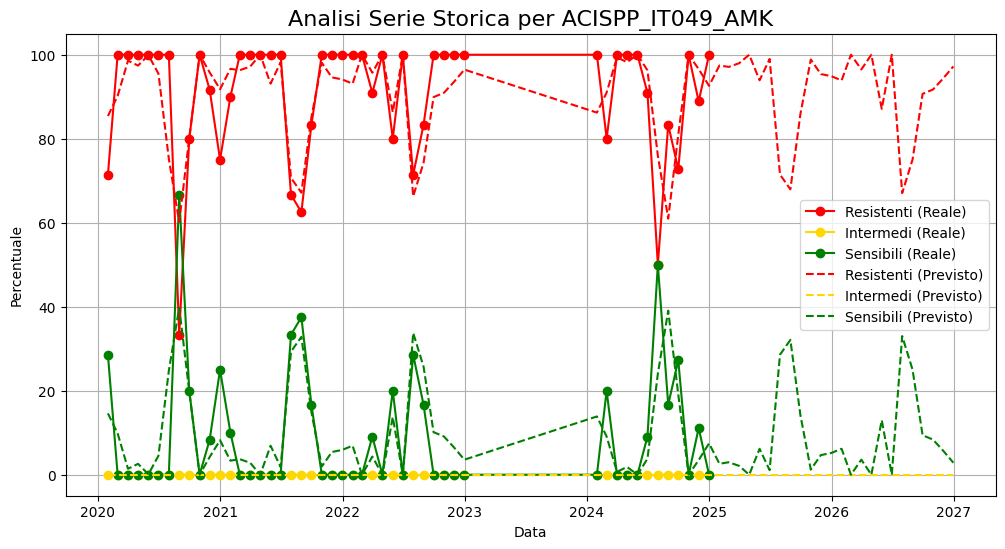

In [ ]:
#Analisi serie storiche

# Carica i dati aggregati (dalla Cella 2)
# Se non sono in memoria, assicurati di caricarli da un file se li hai salvati
try:
    if 'df_aggregato' not in globals():
        print("⚠ Variabile 'df_aggregato' non trovata. Carica i dati.")
        # Esegui la Cella 2 o carica da file
except NameError:
    print("⚠ Variabile 'df_aggregato' non trovata. Carica i dati.")

# Sostituisci questo valore con una delle combinazioni che hai trovato nel Passo 1
combinazione_da_analizzare = 'ACISPP_IT049_AMK'

# Filtra i dati per la combinazione selezionata
df_combinazione_analisi = df_aggregato[df_aggregato['combinazione_unica'] == combinazione_da_analizzare].copy()

# Crea il grafico
plt.figure(figsize=(12, 6))
plt.plot(df_combinazione_analisi['data'], df_combinazione_analisi['resistenti'], label='Resistenti (Reale)', marker='o', linestyle='-', color='red')
plt.plot(df_combinazione_analisi['data'], df_combinazione_analisi['intermedi'], label='Intermedi (Reale)', marker='o', linestyle='-', color='gold')
plt.plot(df_combinazione_analisi['data'], df_combinazione_analisi['sensibili'], label='Sensibili (Reale)', marker='o', linestyle='-', color='green')

# Aggiungi i dati di previsione per la cross-validation se disponibili
try:
    previsioni_res = joblib.load('previsioni_resistenti.pkl')[combinazione_da_analizzare]
    previsioni_int = joblib.load('previsioni_intermedi.pkl')[combinazione_da_analizzare]
    previsioni_sens = joblib.load('previsioni_sensibili.pkl')[combinazione_da_analizzare]

    # Plotta le previsioni (linea tratteggiata)
    plt.plot(previsioni_res['ds'], previsioni_res['yhat'], label='Resistenti (Previsto)', linestyle='--', color='red')
    plt.plot(previsioni_int['ds'], previsioni_int['yhat'], label='Intermedi (Previsto)', linestyle='--', color='gold')
    plt.plot(previsioni_sens['ds'], previsioni_sens['yhat'], label='Sensibili (Previsto)', linestyle='--', color='green')
except (KeyError, FileNotFoundError):
    print("⚠ Dati di previsione non trovati per questa combinazione o i file non esistono.")

plt.title(f'Analisi Serie Storica per {combinazione_da_analizzare}', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Percentuale')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Verifica dei dati 2023-2024

import pandas as pd
import numpy as np

if 'df_aggregato' not in globals():
    print("⚠ df_aggregato non trovato. Assicurati di aver eseguito la Cella 2.")
else:
    # Converti la colonna data in datetime (se non lo è già)
    df_aggregato['data'] = pd.to_datetime(df_aggregato['data'])

    # Raggruppa per data (mese) e somma il Totale_Campioni in quel mese
    df_copertura_mensile = df_aggregato.groupby(df_aggregato['data'].dt.to_period('M'))['Totale_Campioni'].sum().reset_index()

    # Converte 'data' da Period a stringa per la stampa
    df_copertura_mensile['data'] = df_copertura_mensile['data'].astype(str)

    # Filtra i risultati per mostrare solo il 2023 e il 2024 (dove si trova il tratto piatto)
    df_analisi = df_copertura_mensile[df_copertura_mensile['data'].str.startswith(('2023', '2024'))].copy()

    print("--- Analisi della Copertura Mensile (Totale Campioni) ---")
    print(df_analisi.to_string(index=False))

    # Individuazione automatica dell'ultima data di dati significativi
    ultima_data_significativa = df_analisi[df_analisi['Totale_Campioni'] > 0]['data'].max()
    print(f"\nUltima data con campioni totali > 0: {ultima_data_significativa}")

    # Calcolo della media mensile per un confronto
    media_mensile_storica = df_copertura_mensile[df_copertura_mensile['data'].str.startswith('2023')]['Totale_Campioni'].mean()
    print(f"Media campioni mensili nel 2023: {media_mensile_storica:,.0f}")

--- Analisi della Copertura Mensile (Totale Campioni) ---
   data  Totale_Campioni
2023-01          19456.0
2023-02          20801.0
2023-03          24839.0
2023-04          21071.0
2023-05          24674.0
2023-06          25917.0
2023-07          24049.0
2023-08          29027.0
2023-09          27381.0
2023-10          28745.0
2023-11          27296.0
2023-12          22571.0
2024-01          28823.0
2024-02          28425.0
2024-03          29782.0
2024-04          29979.0
2024-05          33411.0
2024-06          32258.0
2024-07          34659.0
2024-08          35988.0
2024-09          34154.0
2024-10          36710.0
2024-11          32743.0
2024-12          29795.0

Ultima data con campioni totali > 0: 2024-12
Media campioni mensili nel 2023: 24,652


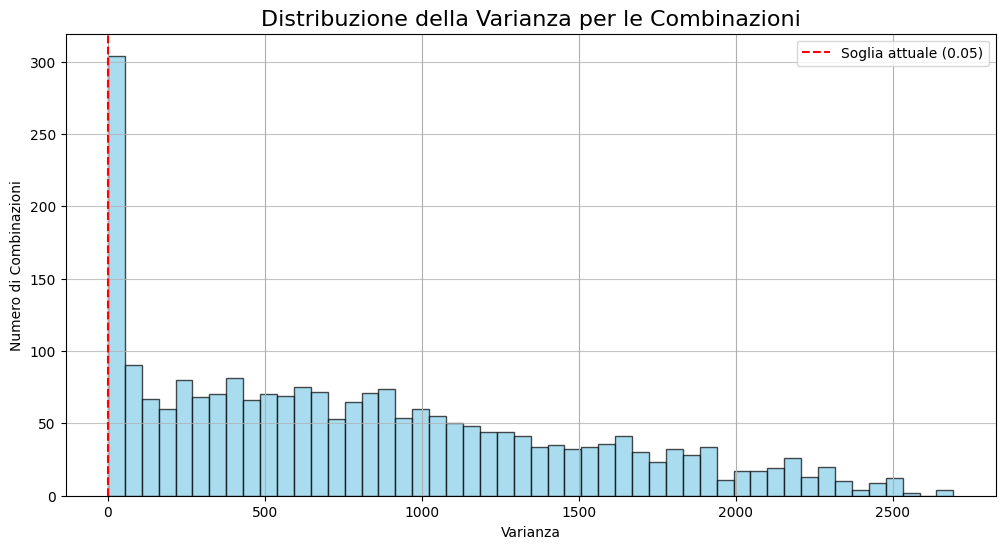


--- Valori di Varianza più comuni ---
count    2354.000000
mean      821.683292
std       658.120352
min         0.000000
25%       262.144024
50%       707.973761
75%      1264.659433
max      2692.307692
dtype: float64

--- Top 10 Varianze più basse ---
combinazione_unica
STAAUR_IT169_TGC    0.0
PSEAER_IT176_FOS    0.0
ESCCOL_IT244_IPM    0.0
ESCCOL_IT244_MEM    0.0
STAAUR_IT168_CPT    0.0
ENTFAE_IT174_LNZ    0.0
ENTFAE_IT168_VAN    0.0
ENTFAE_IT169_TGC    0.0
STAAUR_IT170_FOX    0.0
ENTFAE_IT172_TGC    0.0
dtype: float64

--- Top 10 Varianze più alte ---
combinazione_unica
ENTFCM_IT170_FOS    2500.000000
PSEAER_IT161_CIP    2500.000000
ACISPP_IT049_COL    2515.262515
STRPNE_IT163_CLI    2515.262515
ACISPP_IT171_STH    2564.102564
KLEPNE_IT133_AMP    2580.645161
ESCCOL_IT173_TCY    2651.515152
ACISPP_IT171_RIF    2666.666667
PSEAER_IT167_GEN    2666.666667
STRPNE_IT173_ERY    2692.307692
dtype: float64


In [ ]:
#Varianza
if 'df_aggregato' not in globals():
    print("⚠ Variabile 'df_aggregato' non trovata. Esegui la Cella 2 per caricare i dati.")
else:
    # Filtra i dati solo per le combinazioni valide
    df_filtrato = df_aggregato[df_aggregato['data'].dt.year >= 2019].copy()
    conteggi_per_combinazione = df_filtrato.groupby('combinazione_unica').size()
    combinazioni_valide = conteggi_per_combinazione[conteggi_per_combinazione >= 12].index
    df_completo_valido = df_filtrato[df_filtrato['combinazione_unica'].isin(combinazioni_valide)].copy()

    # Calcola la varianza per ogni combinazione
    varianze = df_completo_valido.groupby('combinazione_unica')[['resistenti', 'intermedi', 'sensibili']].var().max(axis=1)

    # Crea un istogramma per visualizzare la distribuzione delle varianze
    plt.figure(figsize=(12, 6))
    varianze.hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Distribuzione della Varianza per le Combinazioni', fontsize=16)
    plt.xlabel('Varianza')
    plt.ylabel('Numero di Combinazioni')
    plt.axvline(x=0.05, color='red', linestyle='--', label='Soglia attuale (0.05)')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Stampa i valori di varianza più comuni
    print("\n--- Valori di Varianza più comuni ---")
    print(varianze.describe())

    # Ordina i valori per vedere i più bassi e i più alti
    varianze_ordinate = varianze.sort_values(ascending=True)
    print("\n--- Top 10 Varianze più basse ---")
    print(varianze_ordinate.head(10))
    print("\n--- Top 10 Varianze più alte ---")
    print(varianze_ordinate.tail(10))

In [ ]:
# Mesi mancanti

# --- 1. Analisi di Tutte le Combinazioni ---

if 'df_aggregato' not in globals():
    print("⚠ Variabile 'df_aggregato' non trovata. Esegui la Cella 2 prima di questa.")
else:
    # Assicurati che 'data' sia di tipo datetime e crea la colonna periodica
    df_aggregato['data'] = pd.to_datetime(df_aggregato['data'])
    df_aggregato['periodo_mese'] = df_aggregato['data'].dt.to_period('M')

    # Rimuovi eventuali duplicati in termini di data e combinazione per un conteggio accurato
    df_conteggi_unici = df_aggregato[['periodo_mese', 'combinazione_unica']].drop_duplicates().copy()

    # Calcola il numero di mesi con dati per ogni combinazione
    conteggio_mesi_presenti = df_conteggi_unici.groupby('combinazione_unica').size()

    # Calcola il numero totale di mesi nel periodo di analisi (dal 2019-01 al 2024-12)
    min_date = df_aggregato['data'].min()
    max_date = df_aggregato['data'].max()
    total_months = len(pd.date_range(start=min_date, end=max_date, freq='ME'))

    # Calcola i mesi mancanti
    df_analisi = (total_months - conteggio_mesi_presenti).reset_index(name='mesi_mancanti')

    # Ordina per mostrare le combinazioni con più buchi
    df_analisi_ordinato = df_analisi.sort_values(by='mesi_mancanti', ascending=False)

    print("--- 10 Combinazioni con il Maggior Numero di Mesi Mancanti ---")
    print(df_analisi_ordinato.head(10))

# --- 2. Analisi di una Singola Combinazione ---

    # Sostituisci con la combinazione che vuoi analizzare
    combinazione_da_analizzare = 'STRPNE_IT173_ERY'

    df_specifico = df_aggregato[df_aggregato['combinazione_unica'] == combinazione_da_analizzare].copy()

    if df_specifico.empty:
        print(f"\n⚠ La combinazione '{combinazione_da_analizzare}' non è stata trovata.")
    else:
        # Crea un intervallo di date completo
        date_completo = pd.date_range(start=df_specifico['data'].min(), end=df_specifico['data'].max(), freq='ME')

        # Trova le date presenti nel dataset
        date_presenti = set(df_specifico['data'].dt.to_period('M'))

        # Trova le date mancanti
        date_mancanti = [d for d in date_completo.to_period('M') if d not in date_presenti]

        print(f"\n--- Mesi Mancanti per la Combinazione '{combinazione_da_analizzare}' ---")
        if date_mancanti:
            print(f"La combinazione ha {len(date_mancanti)} mesi mancanti.")
            print("Elenco dei mesi mancanti:")
            print(date_mancanti)
        else:
            print("Questa combinazione non ha mesi mancanti nel periodo di analisi.")


--- 10 Combinazioni con il Maggior Numero di Mesi Mancanti ---
     combinazione_unica  mesi_mancanti
3941   STRPNE_IT180_MEM             71
3906   STRPNE_IT176_OXA             71
29     ACISPP_IT133_TZP             71
27     ACISPP_IT133_TCY             71
20     ACISPP_IT133_CZA             71
19     ACISPP_IT133_CRO             71
3902   STRPNE_IT176_IPM             71
3901   STRPNE_IT176_DAP             71
3897   STRPNE_IT176_CIP             71
3890   STRPNE_IT175_CRO             71

--- Mesi Mancanti per la Combinazione 'STRPNE_IT173_ERY' ---
La combinazione ha 50 mesi mancanti.
Elenco dei mesi mancanti:
[Period('2019-06', 'M'), Period('2019-08', 'M'), Period('2019-09', 'M'), Period('2019-10', 'M'), Period('2019-11', 'M'), Period('2019-12', 'M'), Period('2020-01', 'M'), Period('2020-04', 'M'), Period('2020-05', 'M'), Period('2020-06', 'M'), Period('2020-07', 'M'), Period('2020-08', 'M'), Period('2020-09', 'M'), Period('2020-10', 'M'), Period('2020-11', 'M'), Period('2020-12', 'M')

In [ ]:
# ultimo mese utile di dati
import pandas as pd
import numpy as np

if 'df_aggregato' not in globals():
    print("⚠ df_aggregato non trovato. Assicurati di aver eseguito la Cella 2.")
else:
    # Converti la colonna data in datetime (se non lo è già)
    df_aggregato['data'] = pd.to_datetime(df_aggregato['data'])

    # Raggruppa per data (mese) e somma il Totale_Campioni in quel mese
    # 'Totale_Campioni' è la somma di tutti i test (R+I+S) in quel mese
    df_copertura_mensile = df_aggregato.groupby(df_aggregato['data'].dt.to_period('M'))['Totale_Campioni'].sum().reset_index()

    # Converte 'data' da Period a stringa per la stampa
    df_copertura_mensile['data'] = df_copertura_mensile['data'].astype(str)

    # Filtra i risultati per mostrare solo il 2023 e il 2024 (dove si trova il tratto piatto)
    df_analisi = df_copertura_mensile[df_copertura_mensile['data'].str.startswith(('2023', '2024'))].copy()

    print("--- Analisi della Copertura Mensile (Totale Campioni) ---")
    print(df_analisi.to_string(index=False))

    # Calcolo della media mensile per un confronto (usiamo il 2023 come riferimento)
    media_mensile_storica = df_copertura_mensile[df_copertura_mensile['data'].str.startswith('2023')]['Totale_Campioni'].mean()
    print(f"\nMedia campioni mensili nel 2023: {media_mensile_storica:,.0f}")

--- Analisi della Copertura Mensile (Totale Campioni) ---
   data  Totale_Campioni
2023-01          19456.0
2023-02          20801.0
2023-03          24839.0
2023-04          21071.0
2023-05          24674.0
2023-06          25917.0
2023-07          24049.0
2023-08          29027.0
2023-09          27381.0
2023-10          28745.0
2023-11          27296.0
2023-12          22571.0
2024-01          28823.0
2024-02          28425.0
2024-03          29782.0
2024-04          29979.0
2024-05          33411.0
2024-06          32258.0
2024-07          34659.0
2024-08          35988.0
2024-09          34154.0
2024-10          36710.0
2024-11          32743.0
2024-12          29795.0

Media campioni mensili nel 2023: 24,652
